# Importing Libraries

In [5]:
import pandas as pd
import numpy as np

import geopandas as gpd
import folium
from folium.plugins import HeatMap
import pydeck as pdk
import hashlib


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from shapely import wkt

# Loading DF

In [3]:
pre_norm_df_final = pd.read_csv('Data\\display_rdy_data_4.csv', low_memory=False)
norm_df = pd.read_csv('Data\\norm_data_5.csv', low_memory=False)


# PCA

In [ ]:
# # Run PCA and automatically find the optimal components
# # We initially set the n_components to 85% in order to keep 85% of the original information and lose only 15%
# pca_optimal = PCA(n_components=0.85, random_state=42)
# X_pca = pca_optimal.fit_transform(X_scaled)

# # Extract number of needed components
# best_n = pca_optimal.n_components_
# print(f"To retain 85% of the data's variance, PCA selected {best_n} components.")

# # Generate PCA columns
# pca_columns = [f"PCA_{i}" for i in range(1, best_n + 1)]

# Clustering KMEANS

In [ ]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:\n", labels)
    print("===================")
    print("Cluster Counts:\n", labels.value_counts())


In [107]:
# Drop incident zip column
Features = norm_df.drop("Incident_Zip", axis=1)

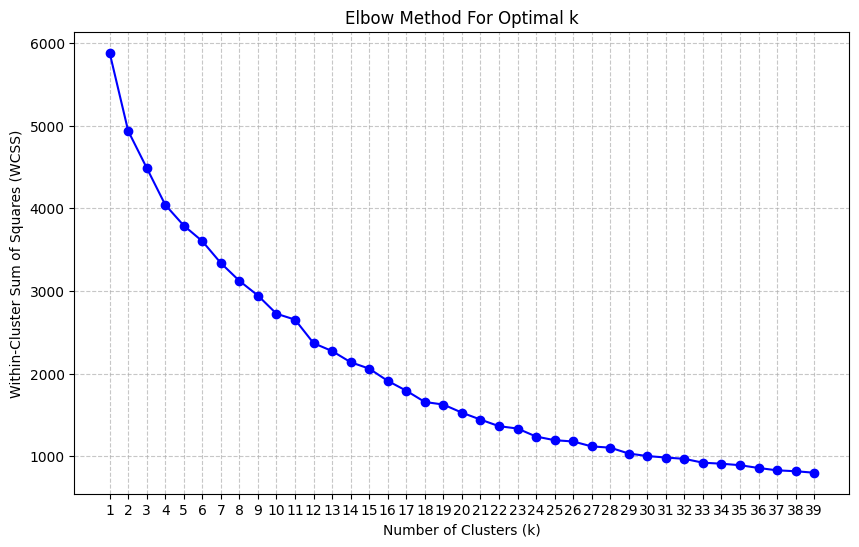

In [108]:
# Calculate WCSS (Inertia) for different values of k
wcss = []
k_range = range(1, 40) # Testing k=1 through k=14

for k in k_range:
    # random_state ensures reproducible results
    # n_init=10 suppresses future warnings in scikit-learn
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Features)
    wcss.append(kmeans.inertia_)

# 4. Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=15,random_state=42, n_init="auto").fit(Features)
labels = kmeans.labels_
pre_norm_df_final["Cluster"] = labels
output(labels)

The labels:
 0       4
1       0
2       2
3       3
4       2
       ..
240     1
241     2
242     1
243     1
244    13
Length: 245, dtype: int32
Cluster Counts:
 2     93
3     45
14    33
0     31
5     17
4     10
1      4
12     3
11     2
9      2
8      1
6      1
10     1
7      1
13     1
Name: count, dtype: int64
